In [279]:
import numpy as np
import matplotlib.pyplot as plt
import random

from scipy.optimize import linear_sum_assignment

### model definition

The model assigns every agent $x$ a random external and desired attribute: $x_\mathrm{ext}, x_\mathrm{des} \sim \mathcal{U}(0, 1)$. The attraction of agent $x$ towards agent $y$ is defined as $u_x(y) = 1 - |x_\mathrm{des} - y_\mathrm{ext}|$.
For an agent $x$, the average amount of attraction towards her is 
$$1 - \int_0^1 |t - x_\mathrm{ext}|\ dt =1 -  \int_0^{x_\mathrm{ext}}x_\mathrm{ext}-t\ dt + \int_{x_\mathrm{ext}}^1t - x_\mathrm{ext}\ dt =1 - \left[x_\mathrm{ext}t - \frac{1}{2}t^2\right]_0^{x_\mathrm{ext}} + \left[\frac{1}{2}t^2 - x_\mathrm{ext}t \right]_{x_\mathrm{ext}}^1 $$
$$ =1 -  x_\mathrm{ext}^2 + \frac{1}{2} - x_\mathrm{ext} = \frac{3}{4} - \left(x_\mathrm{ext} - \frac{1}{2}\right)^2 $$

Which has a maximum of $\frac{3}{4}$ at $x_\mathrm{ext} = \frac{1}{2}$ and a minimum of $\frac{1}{2}$ at the extremes.

When it is an agents turn to make a proposal, it considers all candidates of the opposite gender and weighs the benefit of finding a more compatible partner with the risk of rejection and ending up single (we make the simplification that proposing to another agent means automatically leaving the current partner regardless of acceptance/rejection). We calculate the expected utility as such:

$$ u_x[\mathrm{propose\ to\ }y] = p \cdot u_x(y) + (1 - p) \cdot u_\mathrm{single} $$
where $p$ is the probability of acceptance, which cannot be derived exactly due to the complexity of the system. Since we know that agent $y$ tries to find the most compatible partner, we can estimate their desired attribute as the most recent partner whether current or an ex (which also adds the realistic element of limited memory of the agents). Thus the agent estimates how attracted $y$ will be to them as $\bar{u}_y(x) = 1 - |\bar{y}_\mathrm{des} - x_\mathrm{ext}|$. In the case that $y$ has no previous relationships, agent $x$ falls back to the average attractiviness previously derived.

The estimated reciprocated attraction is mapped to a probability of acceptance using a function
$$ p(\bar{u}_y(x)):[0,1] \to [0,1] $$
The definition of this function is arbitrary, but it should at least be strictly increasing (higher estimated attraction leads to greater probability of acceptance). We choose a simple exponential function
$$ p(x) = e^{\lambda(x-1)}$$
Where $\lambda$ can be interpreted as a degree of risk aversion.

Given a particular state of the system, both making and considering the proposal are deterministic processes. We forsee that this system can cause irrational behaviour when agents repeadetly propose to the same agent and get rejected. To alleviate this, we make the agents avoid the agents they got rejected by. 

For every step of the model we all agents consider their current situation and evaluate whether to propose or not in a random order.

### free parameters

As it stands the model has two free parameters: <br>
-$u_\mathrm{single} \in [0,1]$: the utility of being single, should be higher than 0 since it's better to be alone than with someone you're not compatible with <br>
-$\lambda > 0$: the degree of risk aversion

Potentially we could add a loyalty parameter, where an agent only accepts offers if they are significantly better than their current situation.

In [ ]:
singleU = .5

class Player():
    def __init__(
        self, 
        gender=0, 
        attr=None, 
        desired=None, 
        lamb=.9,
    ):  
        self.gender = gender
        self.lamb = lamb
        
        if (attr == None):
            self.attr = random.random()
        elif (attr >= 0 and attr <= 1):
            self.attr = attr
        else:
            print("Invalid attr argument")
            return

        if (desired == None):
            self.desired = random.random()
        elif (desired >= 0 and desired <= 1):
            self.desired = desired
        else:
            print("Invalid desired argument")
            return
        

        
        self.currPartner = None
        self.currPartnerU = singleU
        self.partnerHistory = []
        self.rejectionHistory = []

        return
    
    def estimateProbAccept(self, utility):
        return np.exp(self.lamb * (utility - 1))
    
    def switchPartner(self, newPartner):
        # leave current partner if it exists
        if (self.currPartner != None):
            self.currPartner.currPartner = None
            self.currPartner.currPartnerU = singleU
            
            # treat leaving as rejection to block reproposals
            self.currPartner.rejectionHistory.append(self)

        # update current partner
        self.currPartner = newPartner
        self.currPartnerU = 1 - abs(self.desired - newPartner.attr)
        self.partnerHistory.append(newPartner) 

        return
    
    def evaluateCandidate(self, candidate):
        attraction = 1 - abs(self.desired - candidate.attr)

        # estimate the candidate's desired attr
        if (len(candidate.partnerHistory) == 0):
            # no information yet, use average distance between self and all possible candidates
            candidateUtility = .75 - (self.attr - 0.5) ** 2
        else:
            estimatedDesired = candidate.partnerHistory[-1].attr

            candidateUtility = 1 - abs(estimatedDesired - self.attr)

        # agent makes an estimation of the probability of acceptance
        probAcceptance = self.estimateProbAccept(candidateUtility)

        # evaluating the strategies using expected utility
        acceptanceEU = (attraction - self.currPartnerU) * probAcceptance
        rejectionEU = (singleU - self.currPartnerU) * (1 - probAcceptance)

        if (acceptanceEU + rejectionEU > 0):
            # proposing to this candidate is beneficial
            # return expected utility gain to compare between candidates
            return acceptanceEU + rejectionEU
        else:
            return 0
        
    def doProposal(self, candidates):
        # store tuples of expected utilities and candidate pointers
        utilities = []
        for candidate in candidates:
            # ignore if same gender or previously rejected
            if (candidate.gender != self.gender and candidate not in self.rejectionHistory):
                utilities.append((self.evaluateCandidate(candidate), candidate))

        # do nothing if no candidates left at all
        if (len(utilities) == 0):
            return
        
        bestCandidate = max(utilities, key=lambda c:c[0])

        # is best candidate better than current?
        if (bestCandidate[0] > 0):
            # send proposal and handle result
            accepted = bestCandidate[1].handleProposal(self)

            if (accepted):
                self.switchPartner(bestCandidate[1])
            else:
                # record rejection
                self.rejectionHistory.append(bestCandidate[1])

        return
    
    def handleProposal(self, candidate):
        candidateU = 1 - np.abs(self.desired - candidate.attr)

        # accept if better than current partner
        if (candidateU > self.currPartnerU):
            self.switchPartner(candidate)
            return True
            
        return False
        

class Model:
    def __init__(
        self,
        Nplayers,
        genderBalance=.5,
        lamb=1
    ):  
        self.Nplayers = Nplayers
        Nmales = int(Nplayers * genderBalance)

        self.males = [Player(0, lamb=lamb) for i in range(Nmales)]
        self.females = [Player(1, lamb=lamb) for i in range(Nplayers - Nmales)]
        self.players = self.males + self.females

        return
    
    def step(self):
        # use random turn order
        random.shuffle(self.players)

        for player in self.players:
            player.doProposal(self.players)

        return
    
    def relationshipPrevalence(self):
        inRelationship = 0
        for player in self.players:
            if (player.currPartner != None):
                inRelationship += 1

        return inRelationship / self.Nplayers
    
    def ideality(self):
        # ideality in terms of global utiliy 
        # 1 = perfect assignment by an overseeing matchmaker
        totU = 0
        for player in self.players:
            totU += player.currPartnerU

        return totU / self.calculate_max_possible_utility()
    
    def averageRejections(self):
        totRejections = 0
        for player in self.players:
            totRejections += len(player.rejectionHistory)

        return totRejections / self.Nplayers

    def calculate_max_possible_utility(self):
        # gemini's work
        Nm = len(self.males)
        Nf = len(self.females)
        
        # Edge case protection
        if Nm == 0 or Nf == 0:
            return singleU
            
        utility_matrix = np.zeros((Nm, Nf))
        
        for i, m in enumerate(self.males):
            for j, f in enumerate(self.females):
                # The male evaluates the female's attribute
                u_m = 1.0 - abs(m.desired - f.attr)
                
                # FIXED: The female evaluates the male's attribute
                u_f = 1.0 - abs(f.desired - m.attr)
                
                # If coupling is worse than both staying single, 
                # they are assigned the "stay single" combined utility.
                utility_matrix[i, j] = max(u_m + u_f, 2 * singleU)
                
        # Maximize the utility (Scipy minimizes, so we pass negative)
        row_ind, col_ind = linear_sum_assignment(-utility_matrix)
        
        # Sum the utilities of all matched pairs
        max_total_utility = utility_matrix[row_ind, col_ind].sum()
        
        # Add the baseline utility for leftover people forced to be single 
        # because of a gender imbalance (e.g., 60 males, 40 females = 20 unmatched)
        unmatched_count = abs(Nm - Nf)
        max_total_utility += unmatched_count * singleU
        
        # FIXED: Divide by the total number of players to get the true average maximum
        return max_total_utility

        

    

Text(0.5, 1.0, 'Average utility')

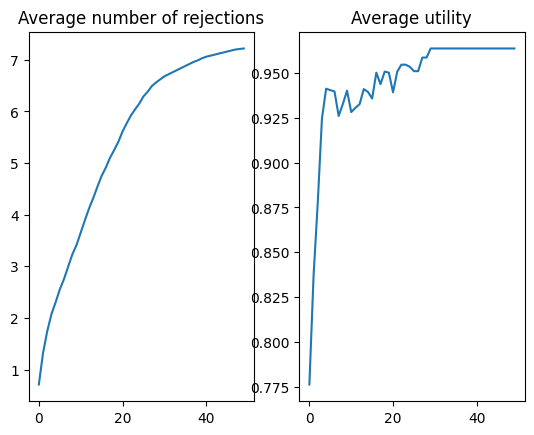

In [293]:
loveIsland = Model(100, lamb=2)

relationshipPrevalence = []
ideality = []
averageRejections = []
for i in range(50):
    loveIsland.step()
    relationshipPrevalence.append(loveIsland.relationshipPrevalence())
    ideality.append(loveIsland.ideality())
    averageRejections.append(loveIsland.averageRejections())

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(averageRejections)
ax1.set_title("Average number of rejections")
ax2.plot(ideality)
ax2.set_title("Average utility")





lambda =  0.1
lambda =  0.5333333333333333
lambda =  0.9666666666666667
lambda =  1.4000000000000001
lambda =  1.8333333333333335
lambda =  2.266666666666667
lambda =  2.7
lambda =  3.1333333333333333
lambda =  3.566666666666667
lambda =  4.0


Text(0.5, 0, '$\\lambda$')

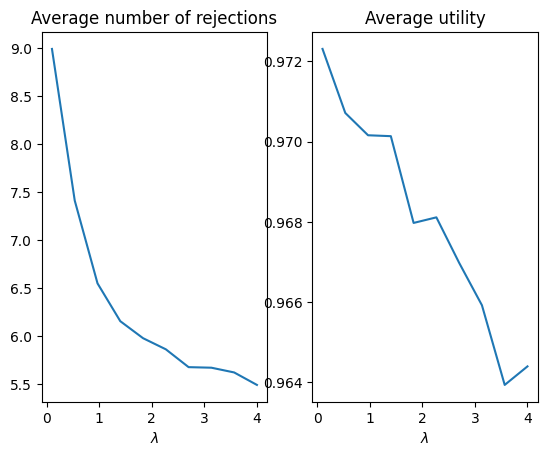

In [295]:
lambdas = np.linspace(0.1, 4, 10)
Nplayers = 100
Nruns = 200
Nsteps = 50

averageRejections = []
ideality = []

for lamb in lambdas:
    print("lambda = ", lamb)
    avgRej = []
    avgUtil = []
    for i in range(Nruns):
        tempModel = Model(Nplayers, lamb=lamb)
        for i in range(Nsteps):
            tempModel.step()

        avgRej.append(tempModel.averageRejections())
        avgUtil.append(tempModel.ideality())

    averageRejections.append(sum(avgRej) / len(avgRej))
    ideality.append(sum(avgUtil) / len(avgUtil))

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(lambdas, averageRejections)
ax1.set_title("Average number of rejections")
ax1.set_xlabel("$\\lambda$")
ax2.plot(lambdas, ideality)
ax2.set_title("Average utility")
ax2.set_xlabel("$\\lambda$")  
